# Learning Curve Analysis — Cross-Dataset LOFO

Per-epoch train/val loss & accuracy for `04_cross_dataset_training.py` LOFO runs.

Companion to `learning_curve_analysis.ipynb` (which reads `03_main_training.py`'s
`classification_performances.joblib`, keyed `{exp_title: {mode: {filter: res_entry}}}`).
Cross-dataset results are keyed `{fold_label: {filter: res_entry}}` instead (mode/
curve_type/model are baked into the file path, not dict keys — see `04_output_map.md`),
and live across one file per `(filter, model)` rather than one shared file, so this
notebook loads via `load_partitioned()` instead of a single `joblib.load()`. Everything
downstream (`train_history_{model}_` = list of Keras `History.history` dicts) is the
exact same mechanism `03`/`04` both write through `evaluate_outlier_filters`, so the
plotting helpers below are carried over unchanged from `learning_curve_analysis.ipynb`.

**Note on LOFO's own "folds":** each `fold_label` here is one *held-out chip*, not a
repeated k-fold of the same distribution — so `train_history_{model}_` for a given
(fold_label, filter) is typically a **list of length 1** (one `--train_full`-style
train/test split per fold), not several repeats to average over. Section 7 below
(comparing one model's curve *across* held-out chips) is the more natural "many curves"
view for LOFO than section 4/5's single-fold panel.

In [1]:
import os, sys, importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

sys.path.insert(0, 'utils')
from cross_dataset_result_io import load_partitioned

# Reuse 06b's legacy-path finder as load_partitioned's fallback, exactly like
# 04/06b/08 do -- see utils/cross_dataset_result_io.py's docstring.
b06 = importlib.import_module("06b_cross_dataset_prediction_report")

%matplotlib inline

Current Working Directory: /rds/general/user/gk225/home/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1 — Point this at the run you want to analyse

In [2]:
# ── Point this at the group/run whose learning curves you want ─────────────
EXP_FOLDER = config.FINAL_EXP_FOLDER + "_nc_subtract"
GROUP_NAME = "final_4_chip_clean_nn"
MODE_STR   = "lofo"              # matches --mode (kfold N -> "kfold{N}", e.g. "kfold5")
CURVE_TYPE = "ori_curve_norm"

CURVE_ALIGNMENT = "acquisition_start"   # "acquisition_start" | "pc_ttp"
PC_TTP_ANCHOR   = "min"                 # only used when CURVE_ALIGNMENT == "pc_ttp"

out_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME
if CURVE_ALIGNMENT == "pc_ttp":
    out_dir = out_dir / "curve_alignment_pc_ttp" / f"anchor_{PC_TTP_ANCHOR}"

legacy_path = b06.find_results_path(out_dir, MODE_STR, CURVE_TYPE)
results = load_partitioned(out_dir, MODE_STR, CURVE_TYPE, legacy_path=legacy_path)
assert results, (f"No '{MODE_STR}' results under {out_dir} for curve_type={CURVE_TYPE}. "
                 f"Check EXP_FOLDER/GROUP_NAME/CURVE_TYPE/CURVE_ALIGNMENT above.")
print(f"Loaded {len(results)} fold(s) from {out_dir}")

Loaded 5 fold(s) from /rds/general/user/gk225/home/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn


## 2 — Explorer: what history is available?

In [3]:
for fold_label, fold_res in sorted(results.items()):
    if not isinstance(fold_res, dict):
        continue
    for filter_name, res in fold_res.items():
        if filter_name in ("top_10_features", "class_names") or not isinstance(res, dict):
            continue
        hist_keys = sorted(k for k in res if k.startswith('train_history'))
        if hist_keys:
            models = [k.replace('train_history_', '').rstrip('_') for k in hist_keys]
            print(f"{fold_label} | filter={filter_name}")
            print(f"  models: {models}")
            print()

full_data | filter=None
  models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_coral']

lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06 | filter=None
  models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_coral', 'cnn_gru_dual_supcon3_coral']

lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07 | filter=None
  models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_attn_recon_supcon3_coral', 'cnn_gru_dual_coral', 'cnn_gru_dual_supcon3_coral']

lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01 | filter=None
  models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_attn_recon_supcon3_coral', 'cnn_gru_dual_coral', 'cnn_gru_dual_supcon3_coral']

lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01 | filter=None
  models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_attn_recon_supcon3_coral', 'cnn_gru_dual_coral', 'cnn_gru_dual_supcon3_coral']



## 3 — Pick one held-out fold + filter to inspect

In [4]:
# ── Choose one entry ─────────────────────────────────────────────
TARGET_FOLD   = sorted(k for k in results if k not in ("top_10_features", "class_names"))[0]
TARGET_FILTER = None   # None = baseline; else the outlier_filter string, e.g. "lofo_ae"

res = results[TARGET_FOLD][TARGET_FILTER]
hist_keys = sorted(k for k in res if k.startswith('train_history'))
print(f"Entry : {TARGET_FOLD} | filter={TARGET_FILTER}")
print(f"Models: {[k.replace('train_history_', '').rstrip('_') for k in hist_keys]}")
if hist_keys:
    sample = res[hist_keys[0]][0]
    print(f"Metric keys in first model's history: {list(sample.keys())}")
    print(f"Epochs recorded: {len(sample.get('loss', []))}")

Entry : full_data | filter=None
Models: ['cnn_gru_dual_attn_recon_coral', 'cnn_gru_dual_coral']
Metric keys in first model's history: ['cls_ce', 'cls_out_accuracy', 'coral', 'loss', 'val_cls_ce', 'val_coral', 'val_loss', 'learning_rate']
Epochs recorded: 255


## 4 — Helper functions

Carried over unchanged from `learning_curve_analysis.ipynb`.

In [5]:
def _get(histories, key):
    # List of np arrays (one per fold-run) for a given metric key
    return [np.array(h[key]) for h in histories if key in h]

def _pad_mean(arrays):
    # Nan-padded mean across arrays of different lengths
    if not arrays:
        return np.array([])
    maxlen = max(len(a) for a in arrays)
    padded = np.full((len(arrays), maxlen), np.nan)
    for i, a in enumerate(arrays):
        padded[i, :len(a)] = a
    return np.nanmean(padded, axis=0)

def _best_epoch(histories, val_key='val_loss'):
    # Epoch index of minimum val_loss per fold-run (where available)
    out = []
    for h in histories:
        if val_key in h:
            out.append(int(np.argmin(h[val_key])))
        else:
            out.append(len(h.get('loss', [])) - 1)
    return out

def _detect_metric_keys(history):
    # Return (loss_key, val_loss_key, acc_key, val_acc_key) for this history dict
    keys = set(history.keys())
    lk  = 'loss'
    vlk = 'val_loss' if 'val_loss' in keys else None
    # accuracy -- standard models use 'accuracy'; MTL/DANN/CORAL models use 'cls_out_accuracy'
    if 'accuracy' in keys:
        ak, vak = 'accuracy', ('val_accuracy' if 'val_accuracy' in keys else None)
    elif 'cls_out_accuracy' in keys:
        ak, vak = 'cls_out_accuracy', ('val_cls_out_accuracy' if 'val_cls_out_accuracy' in keys else None)
    else:
        ak, vak = None, None
    return lk, vlk, ak, vak

## 5 — Per-model learning curves (loss + accuracy), this fold

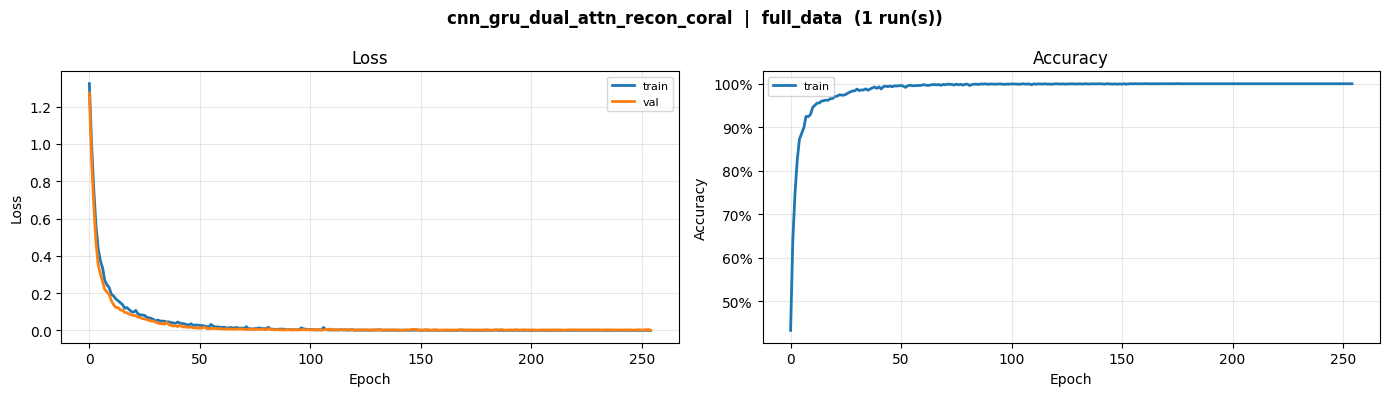

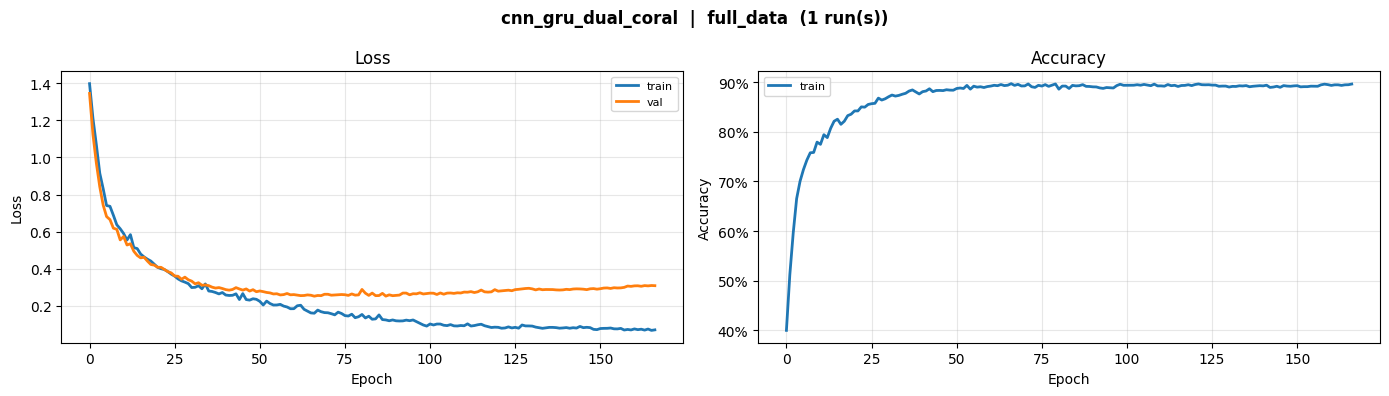

In [6]:
BLUE   = 'tab:blue'
ORANGE = 'tab:orange'
ALPHA  = 0.25

for hist_key in hist_keys:
    model_name = hist_key.replace('train_history_', '').rstrip('_')
    histories  = res[hist_key]
    if not histories:
        continue

    lk, vlk, ak, vak = _detect_metric_keys(histories[0])
    has_val  = vlk is not None
    has_acc  = ak  is not None

    ncols = 1 + int(has_acc)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f"{model_name}  |  {TARGET_FOLD}  ({len(histories)} run(s))", fontsize=12, fontweight='bold')

    ax = axes[0]
    train_l = _get(histories, lk)
    val_l   = _get(histories, vlk) if has_val else []
    for arr in train_l:
        ax.plot(arr, color=BLUE,   alpha=ALPHA, lw=0.8)
    for arr in val_l:
        ax.plot(arr, color=ORANGE, alpha=ALPHA, lw=0.8)
    if train_l:
        ax.plot(_pad_mean(train_l), color=BLUE,   lw=2, label='train')
    if val_l:
        ax.plot(_pad_mean(val_l),   color=ORANGE, lw=2, label='val')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Loss'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    if has_acc:
        ax = axes[1]
        train_a = _get(histories, ak)
        val_a   = _get(histories, vak) if vak else []
        for arr in train_a:
            ax.plot(arr, color=BLUE,   alpha=ALPHA, lw=0.8)
        for arr in val_a:
            ax.plot(arr, color=ORANGE, alpha=ALPHA, lw=0.8)
        if train_a:
            ax.plot(_pad_mean(train_a), color=BLUE,   lw=2, label='train')
        if val_a:
            ax.plot(_pad_mean(val_a),   color=ORANGE, lw=2, label='val')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.set_title('Accuracy'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6 — Convergence: how many epochs did each model train, this fold?

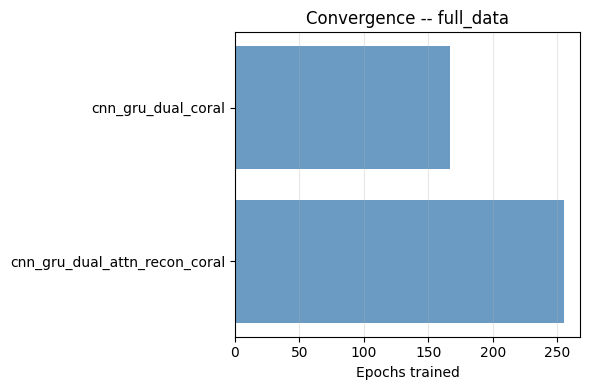

In [7]:
conv_data = {}
for hist_key in hist_keys:
    model_name = hist_key.replace('train_history_', '').rstrip('_')
    histories  = res[hist_key]
    if not histories:
        continue
    epochs_run = [len(h.get('val_loss', h['loss'])) for h in histories]
    conv_data[model_name] = epochs_run

if conv_data:
    fig, ax = plt.subplots(figsize=(max(6, len(conv_data) * 1.2), 4))
    names = list(conv_data.keys())
    vals  = [v[0] for v in conv_data.values()]   # one run per model per fold in LOFO -- no spread to show
    x = np.arange(len(names))
    ax.barh(x, vals, color='steelblue', alpha=0.8)
    ax.set_yticks(x); ax.set_yticklabels(names)
    ax.set_xlabel('Epochs trained')
    ax.set_title(f'Convergence -- {TARGET_FOLD}')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

## 7 — Compare one model's learning curve *across held-out chips*

The more natural "many curves" view for LOFO: same model, same filter, one line per
held-out chip -- shows whether convergence/overfitting behaviour is consistent across
folds or driven by one particular chip.

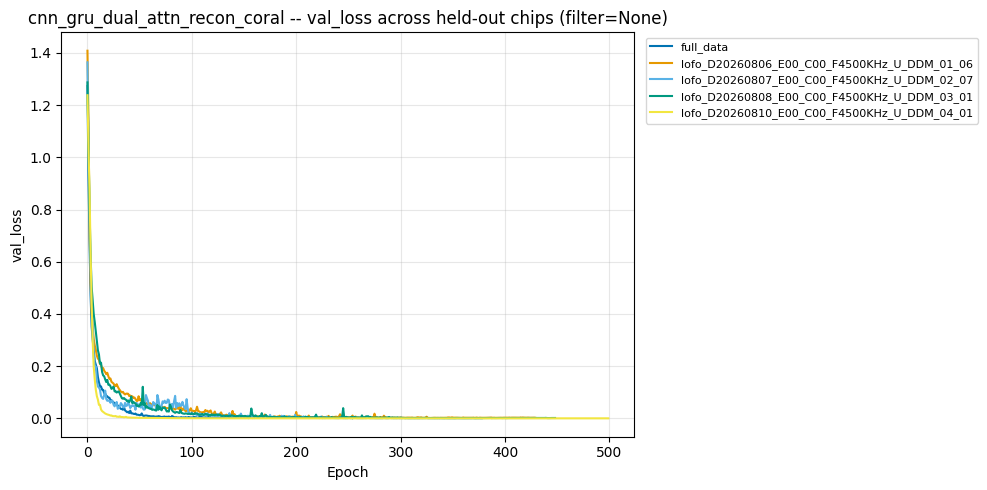

In [8]:
COMPARE_MODEL  = hist_keys[0].replace('train_history_', '').rstrip('_') if hist_keys else None
COMPARE_METRIC = 'val_loss'
COMPARE_FILTER = TARGET_FILTER

fig, ax = plt.subplots(figsize=(10, 5))
found_any = False
for fold_label, fold_res in sorted(results.items()):
    if not isinstance(fold_res, dict) or COMPARE_FILTER not in fold_res:
        continue
    res_e = fold_res[COMPARE_FILTER]
    key = f'train_history_{COMPARE_MODEL}_'
    if key not in res_e:
        continue
    vals = _get(res_e[key], COMPARE_METRIC)
    if not vals:
        continue
    mean_curve = _pad_mean(vals)
    ax.plot(mean_curve, lw=1.5, label=fold_label)
    found_any = True

if found_any:
    ax.set_xlabel('Epoch'); ax.set_ylabel(COMPARE_METRIC)
    ax.set_title(f'{COMPARE_MODEL} -- {COMPARE_METRIC} across held-out chips (filter={COMPARE_FILTER})')
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f"No history found for model '{COMPARE_MODEL}' under filter={COMPARE_FILTER}. "
          f"Check COMPARE_MODEL/COMPARE_FILTER above, or re-run cell 2 to see what's available.")

## 8 — Best val_loss across held-out chips (model comparison)

/var/tmp/pbs.3771848.pbs-7/ipykernel_605821/4270971307.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)


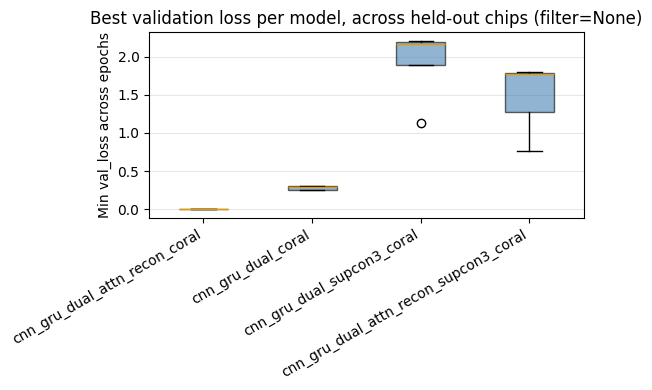

In [9]:
best_val = {}
for fold_label, fold_res in sorted(results.items()):
    if not isinstance(fold_res, dict) or COMPARE_FILTER not in fold_res:
        continue
    res_e = fold_res[COMPARE_FILTER]
    for hist_key in (k for k in res_e if k.startswith('train_history')):
        model_name = hist_key.replace('train_history_', '').rstrip('_')
        for h in res_e[hist_key]:
            if 'val_loss' in h:
                best_val.setdefault(model_name, []).append(float(np.min(h['val_loss'])))

if best_val:
    fig, ax = plt.subplots(figsize=(max(6, len(best_val) * 1.2), 4))
    names = list(best_val.keys())
    data  = list(best_val.values())
    bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
    ax.set_ylabel('Min val_loss across epochs')
    ax.set_title(f'Best validation loss per model, across held-out chips (filter={COMPARE_FILTER})')
    ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
else:
    print(f"No val_loss history found under filter={COMPARE_FILTER}.")